<a href="https://colab.research.google.com/github/Pranav03125/LaundryWateWaterTreatment_ML/blob/main/EC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# Step 1: Data Loading and Overview

import pandas as pd
file_path = '/content/Data_EF Laundry (1).xlsx'
df = pd.read_excel(file_path, sheet_name='Main sheet')

In [39]:
# Display the first few rows to understand structure
print("First 5 rows of dataset:")
print(df.head())


First 5 rows of dataset:
   Set  ESA cm2   flowrate  Volatge  Time  LAS Absorbance  Vol of FAS  \
0    4     2840  1.88L/min        6     0           6.435       10.00   
1    4     2840  1.88L/min        6     5           6.006       10.10   
2    4     2840  1.88L/min        6    10           5.541       10.20   
3    4     2840  1.88L/min        6    15           4.821       10.40   
4    4     2840  1.88L/min        6    20           4.339       10.45   

       COD      COD %  Turbidity       LAS    pH  Current        CD  Power  \
0  50.9184   0.000000        132  1.245682  7.80    3.086  0.001087   19.3   
1  49.6128   2.564103         60  1.136329  7.50    3.199  0.001126   19.2   
2  48.3072   5.128205         42  1.017801  7.30    3.049  0.001074   18.3   
3  47.0000   7.695450         35  0.834273  7.28    2.942  0.001036   17.6   
4  45.8000  10.052162         23  0.711411  7.26    2.865  0.001009   17.2   

   Aluminium (LAS)  
0         0.000000  
1         0.000038  
2   

In [40]:
# General information about data types and non-null counts
print("\nInfo about dataset:")
print(df.info())



Info about dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Set              73 non-null     int64  
 1   ESA cm2          73 non-null     int64  
 2   flowrate         73 non-null     object 
 3   Volatge          73 non-null     int64  
 4   Time             73 non-null     int64  
 5   LAS Absorbance   38 non-null     float64
 6   Vol of FAS       73 non-null     float64
 7   COD              73 non-null     float64
 8   COD %            73 non-null     float64
 9   Turbidity        73 non-null     int64  
 10  LAS              38 non-null     float64
 11  pH               67 non-null     float64
 12  Current          67 non-null     float64
 13  CD               67 non-null     float64
 14  Power            32 non-null     float64
 15  Aluminium (LAS)  31 non-null     float64
dtypes: float64(10), int64(5), object(1)
memory 

In [41]:
# Check for missing values in each column
print("\nMissing values count per column:")
print(df.isnull().sum())


Missing values count per column:
Set                 0
ESA cm2             0
flowrate            0
Volatge             0
Time                0
LAS Absorbance     35
Vol of FAS          0
COD                 0
COD %               0
Turbidity           0
LAS                35
pH                  6
Current             6
CD                  6
Power              41
Aluminium (LAS)    42
dtype: int64


In [42]:
# Descriptive statistics summary for numeric columns
print("\nDescriptive statistics:")
print(df.describe())


Descriptive statistics:
             Set      ESA cm2    Volatge       Time  LAS Absorbance  \
count  73.000000    73.000000  73.000000  73.000000       38.000000   
mean    3.041096  2159.178082  13.232877  16.164384        4.428237   
std     1.337892   949.903143   6.686472  12.734483        1.332227   
min     1.000000   710.000000   6.000000   0.000000        2.220000   
25%     1.000000   710.000000   9.000000   5.000000        3.341500   
50%     4.000000  2840.000000  12.000000  15.000000        4.114000   
75%     4.000000  2840.000000  14.000000  20.000000        5.576000   
max     4.000000  2840.000000  30.000000  40.000000        6.435000   

       Vol of FAS         COD      COD %   Turbidity        LAS         pH  \
count   73.000000   73.000000  73.000000   73.000000  38.000000  67.000000   
mean     9.462055   70.464267   6.854675   62.493151   0.734158   7.015522   
std      0.966661   25.549299   6.965190   45.653624   0.339585   0.304135   
min      8.000000   39.

In [43]:
# Display column names for reference
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Set', 'ESA cm2', 'flowrate', 'Volatge', 'Time', 'LAS Absorbance',
       'Vol of FAS', 'COD', 'COD %', 'Turbidity', 'LAS', 'pH', 'Current', 'CD',
       'Power', 'Aluminium (LAS)'],
      dtype='object')


In [44]:
#Step 2: Data Cleaning and Preprocessing

In [45]:
from sklearn.impute import SimpleImputer
# Drop 'Aluminium (LAS)' column
if 'Aluminium (LAS)' in df.columns:
    df.drop(columns=['Aluminium (LAS)'], inplace=True)

In [46]:
# Convert 'flowrate' from string like "1.88L/min" to float 1.88
df['flowrate'] = df['flowrate'].str.replace('L/min', '').astype(float)


In [47]:
# Explore missing data counts again
print("Missing values per column before imputation:")
print(df.isnull().sum())

Missing values per column before imputation:
Set                0
ESA cm2            0
flowrate           0
Volatge            0
Time               0
LAS Absorbance    35
Vol of FAS         0
COD                0
COD %              0
Turbidity          0
LAS               35
pH                 6
Current            6
CD                 6
Power             41
dtype: int64


In [48]:
# Columns with missing values to consider imputation:
# 'LAS Absorbance', 'LAS', 'pH', 'Current', 'CD', 'Power'

# Impute numeric missing values with median strategy
num_cols_with_missing = ['LAS Absorbance', 'LAS', 'pH', 'Current', 'CD', 'Power']
imputer = SimpleImputer(strategy='median')

df[num_cols_with_missing] = imputer.fit_transform(df[num_cols_with_missing])

In [49]:
# Confirm no missing values remain
print("\nMissing values per column after imputation:")
print(df.isnull().sum())


Missing values per column after imputation:
Set               0
ESA cm2           0
flowrate          0
Volatge           0
Time              0
LAS Absorbance    0
Vol of FAS        0
COD               0
COD %             0
Turbidity         0
LAS               0
pH                0
Current           0
CD                0
Power             0
dtype: int64


In [50]:
# Encode 'Set' as categorical variable (optional but recommended for modeling)
df['Set'] = df['Set'].astype('category')

In [51]:
# Final preview after cleaning and encoding
print("\nData types after processing:")
print(df.dtypes)

print("\nData sample after cleaning:")
print(df.head())


Data types after processing:
Set               category
ESA cm2              int64
flowrate           float64
Volatge              int64
Time                 int64
LAS Absorbance     float64
Vol of FAS         float64
COD                float64
COD %              float64
Turbidity            int64
LAS                float64
pH                 float64
Current            float64
CD                 float64
Power              float64
dtype: object

Data sample after cleaning:
  Set  ESA cm2  flowrate  Volatge  Time  LAS Absorbance  Vol of FAS      COD  \
0   4     2840      1.88        6     0           6.435       10.00  50.9184   
1   4     2840      1.88        6     5           6.006       10.10  49.6128   
2   4     2840      1.88        6    10           5.541       10.20  48.3072   
3   4     2840      1.88        6    15           4.821       10.40  47.0000   
4   4     2840      1.88        6    20           4.339       10.45  45.8000   

       COD %  Turbidity       LAS    pH  

In [52]:
#Step 3: Exploratory Data Analysis (EDA)

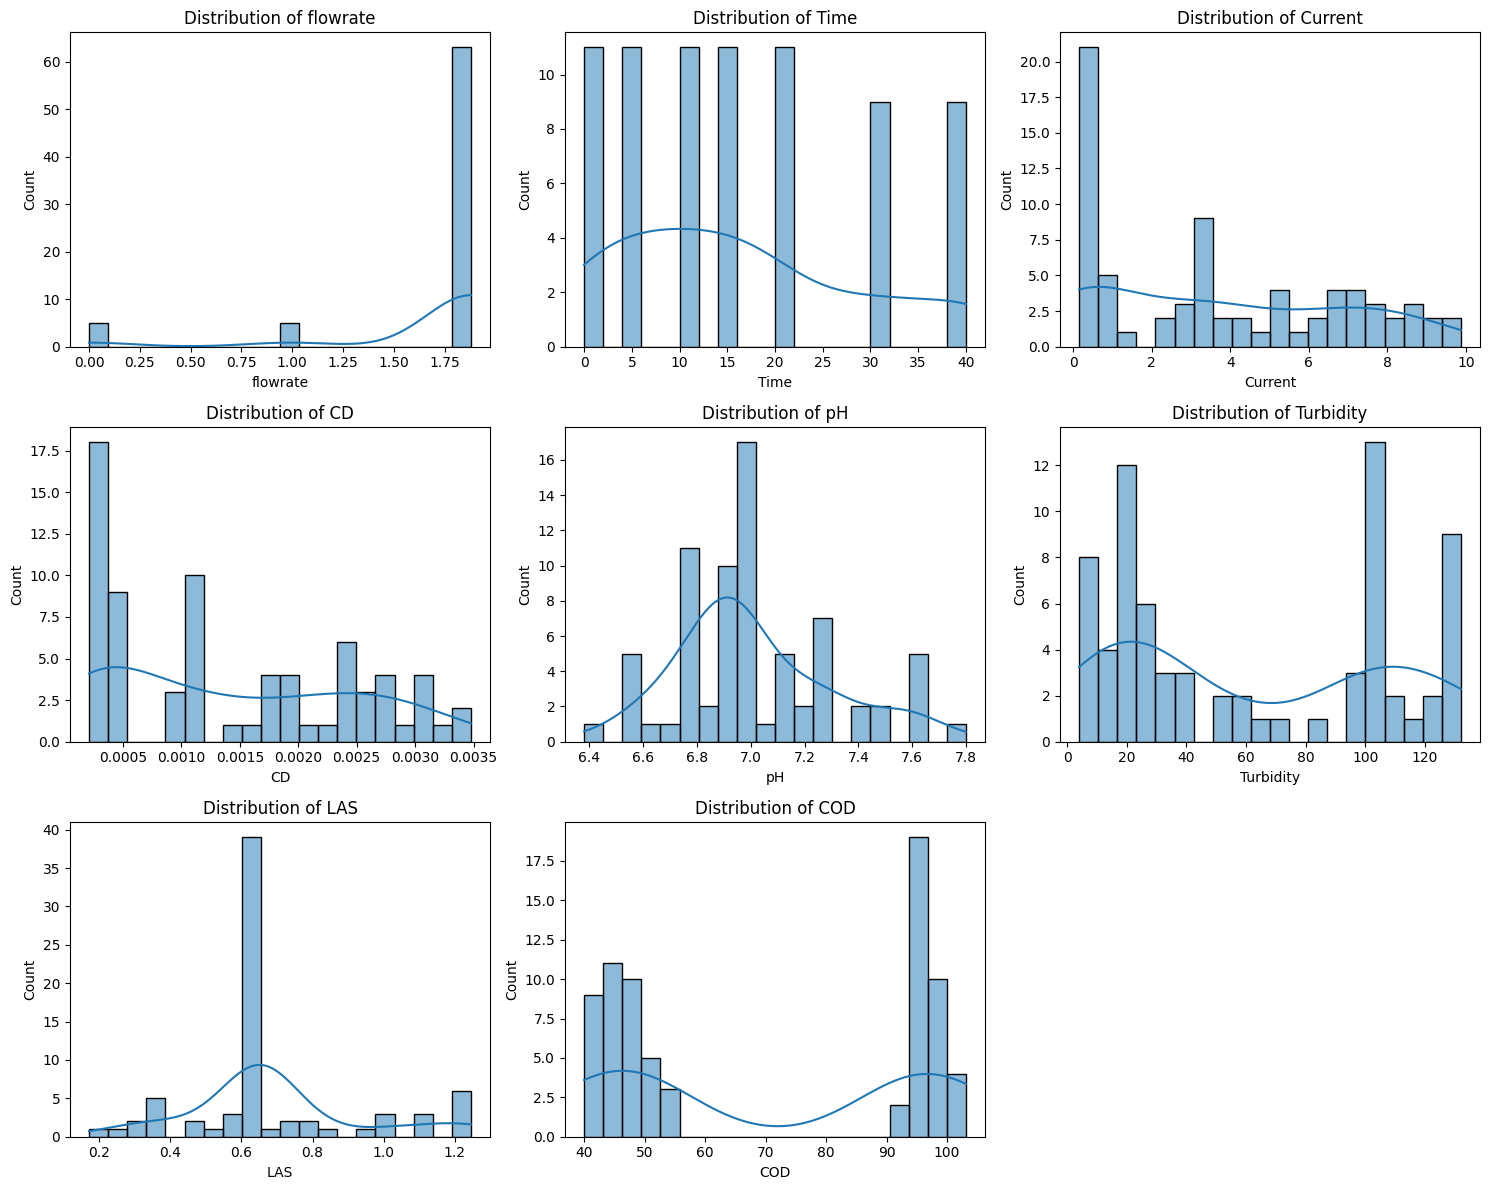

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Distribution plots for key numeric variables
key_vars = ['flowrate', 'Time', 'Current', 'CD', 'pH', 'Turbidity', 'LAS', 'COD']
plt.figure(figsize=(15, 12))
for i, var in enumerate(key_vars, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[var], kde=True, bins=20)
    plt.title(f'Distribution of {var}')
plt.tight_layout()
plt.show()


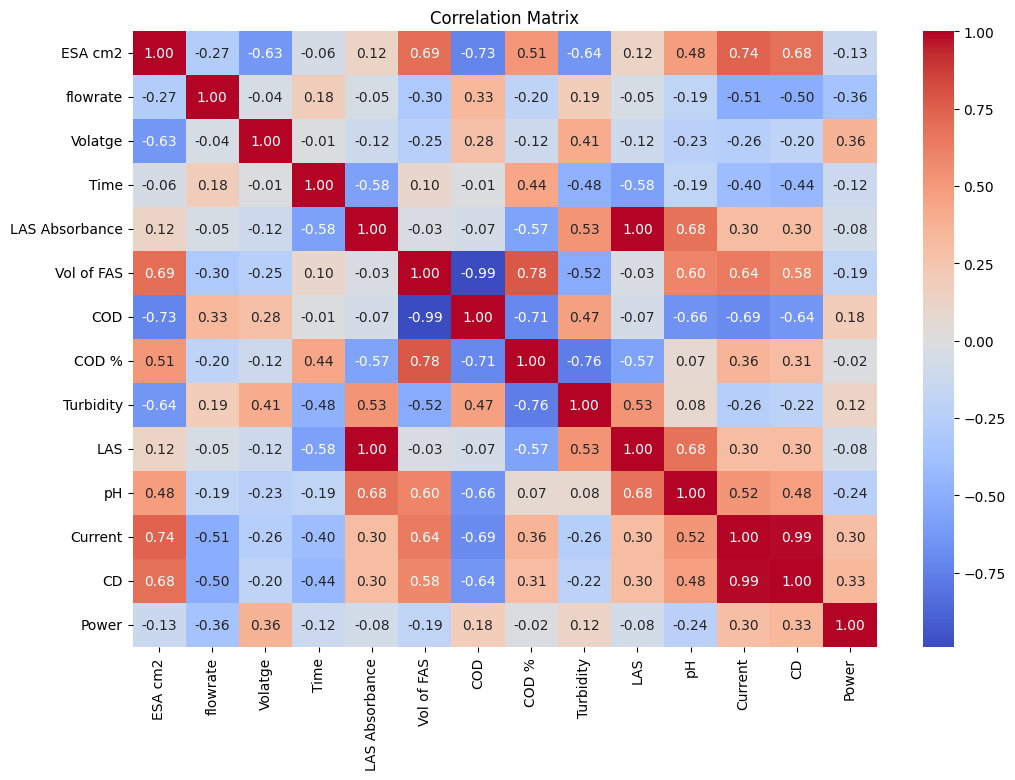

In [54]:
# 2. Correlation matrix heatmap for numeric variables
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

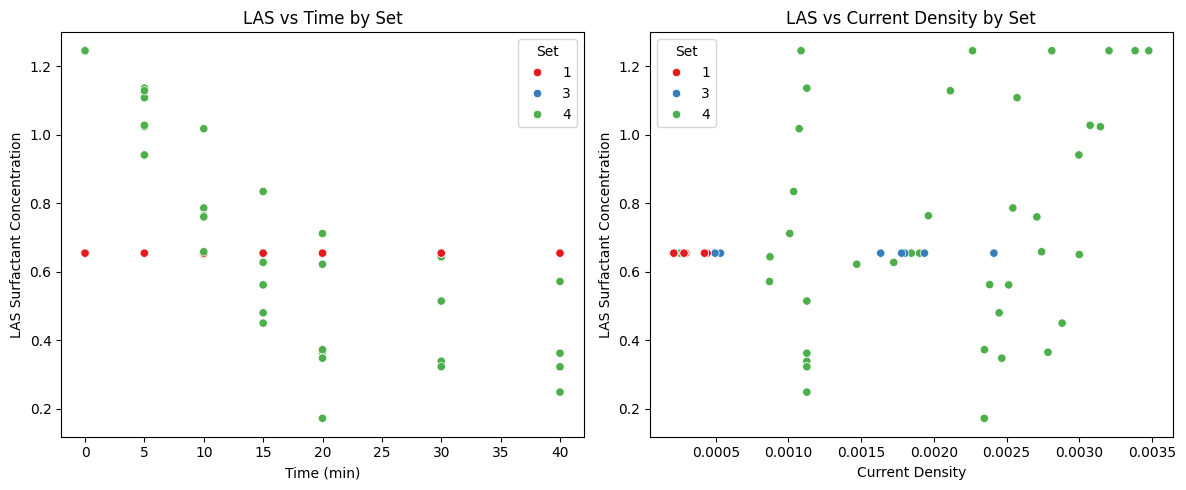

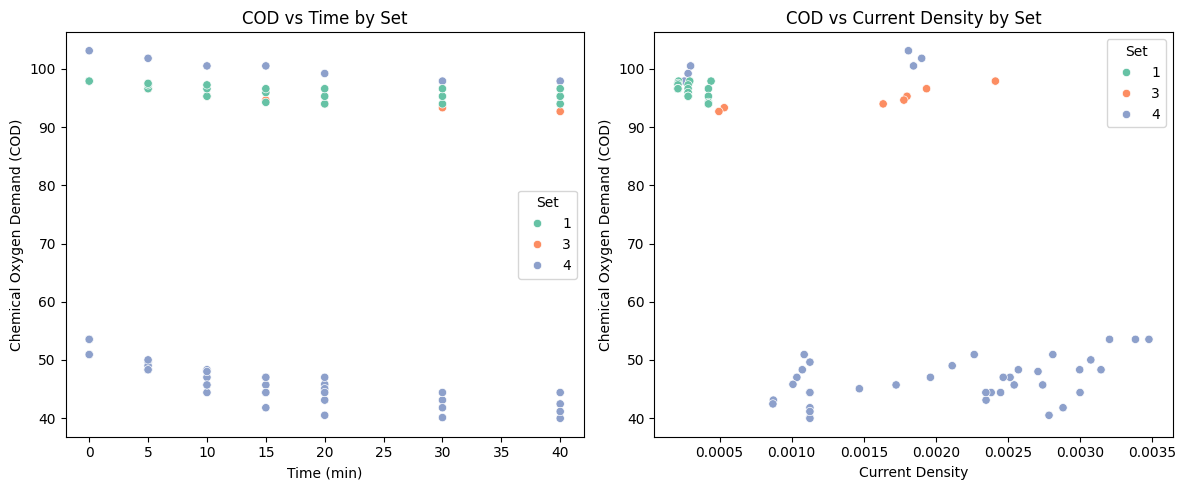

In [55]:
# 3. Scatter plots of LAS and COD vs Time and Current Density
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Time', y='LAS', hue='Set', palette='Set1')
plt.title('LAS vs Time by Set')
plt.xlabel('Time (min)')
plt.ylabel('LAS Surfactant Concentration')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='CD', y='LAS', hue='Set', palette='Set1')
plt.title('LAS vs Current Density by Set')
plt.xlabel('Current Density')
plt.ylabel('LAS Surfactant Concentration')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='Time', y='COD', hue='Set', palette='Set2')
plt.title('COD vs Time by Set')
plt.xlabel('Time (min)')
plt.ylabel('Chemical Oxygen Demand (COD)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='CD', y='COD', hue='Set', palette='Set2')
plt.title('COD vs Current Density by Set')
plt.xlabel('Current Density')
plt.ylabel('Chemical Oxygen Demand (COD)')

plt.tight_layout()
plt.show()


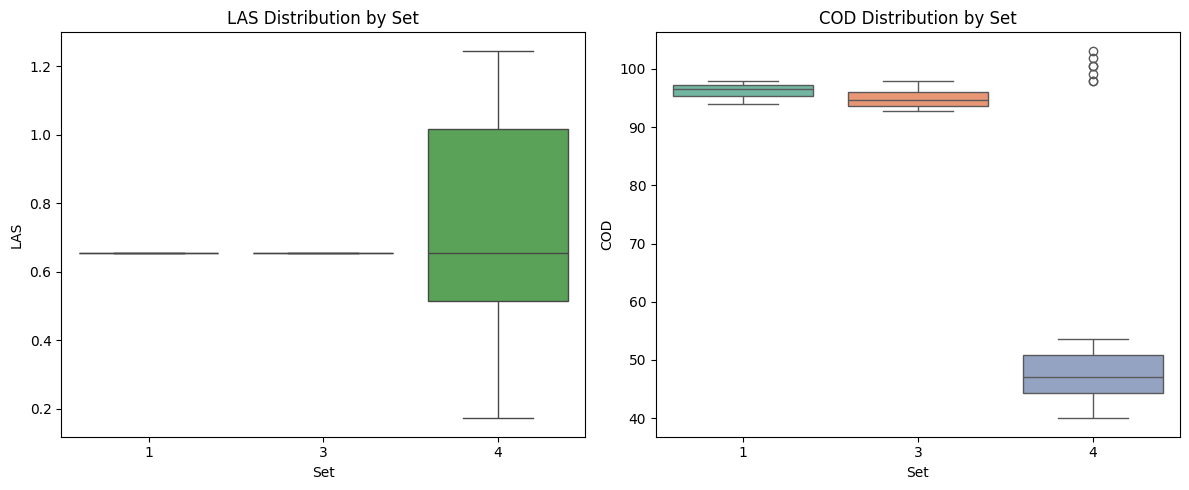

In [56]:
# 4. Boxplot of LAS and COD by 'Set'
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Set', y='LAS', data=df, hue='Set', palette='Set1', legend=False)
plt.title('LAS Distribution by Set')

plt.subplot(1, 2, 2)
sns.boxplot(x='Set', y='COD', data=df, hue='Set', palette='Set2', legend=False)
plt.title('COD Distribution by Set')

plt.tight_layout()
plt.show()

In [57]:
#Step 4: Feature Selection and Engineering

In [58]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [59]:
# Select input features to use for prediction
# Inputs: Set (categorical), flowrate, Time, Current Density (CD), pH, Turbidity
feature_columns = ['Set', 'flowrate', 'Time', 'CD', 'pH', 'Turbidity']

# Outputs/targets
target_columns = ['LAS', 'COD']

# Extract features and target from the dataframe
X = df[feature_columns]
y = df[target_columns]

# Encode categorical variable 'Set' (One-Hot Encoding)
categorical_features = ['Set']
numeric_features = ['flowrate', 'Time', 'CD', 'pH', 'Turbidity']


In [60]:
# Define ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),  # Avoid dummy variable trap
    ],
    remainder='passthrough'  # Numeric features passed without change
)

# Optionally generate polynomial features to capture interactions (degree 2 example)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Combine preprocessing and polynomial feature generation in a pipeline (if polynomial features desired)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', poly)
])

In [61]:
# Fit and transform features
X_transformed = pipeline.fit_transform(X)

In [62]:
# Display shape before and after transformation
print("Original feature shape:", X.shape)
print("Transformed feature shape after encoding and polynomial features:", X_transformed.shape)

# Display first few transformed feature values
print("Sample transformed features (first 5 rows):")
print(X_transformed[:5])

# X_transformed and y are now ready for model training

Original feature shape: (73, 6)
Transformed feature shape after encoding and polynomial features: (73, 35)
Sample transformed features (first 5 rows):
[[0.00000000e+00 1.00000000e+00 1.88000000e+00 0.00000000e+00
  1.08661972e-03 7.80000000e+00 1.32000000e+02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.00000000e+00 1.88000000e+00
  0.00000000e+00 1.08661972e-03 7.80000000e+00 1.32000000e+02
  3.53440000e+00 0.00000000e+00 2.04284507e-03 1.46640000e+01
  2.48160000e+02 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.18074241e-06 8.47563380e-03 1.43433803e-01
  6.08400000e+01 1.02960000e+03 1.74240000e+04]
 [0.00000000e+00 1.00000000e+00 1.88000000e+00 5.00000000e+00
  1.12640845e-03 7.50000000e+00 6.00000000e+01 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.00000000e+00 1.88000000e+00
  5.00000000e+00 1.12640845e-03 7.50000000e+00 6.00000000

In [63]:
#Step 5: Model Preparation and Training

In [64]:
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor

In [65]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=0.2, random_state=42)

In [66]:
# Define models to evaluate
models = {
    'LinearRegression': MultiOutputRegressor(LinearRegression()),
    'RandomForest': MultiOutputRegressor(RandomForestRegressor(random_state=42)),
    'GradientBoosting': MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
}

In [67]:
# Train and evaluate models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluate each output separately
    mae_las = mean_absolute_error(y_test['LAS'], y_pred[:,0])
    mae_cod = mean_absolute_error(y_test['COD'], y_pred[:,1])
    rmse_las = np.sqrt(mean_squared_error(y_test['LAS'], y_pred[:,0]))
    rmse_cod = np.sqrt(mean_squared_error(y_test['COD'], y_pred[:,1]))
    r2_las = r2_score(y_test['LAS'], y_pred[:,0])
    r2_cod = r2_score(y_test['COD'], y_pred[:,1])

    results[name] = {
        'MAE_LAS': mae_las,
        'MAE_COD': mae_cod,
        'RMSE_LAS': rmse_las,
        'RMSE_COD': rmse_cod,
        'R2_LAS': r2_las,
        'R2_COD': r2_cod
    }


In [68]:
# Display results
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"  MAE (LAS): {metrics['MAE_LAS']:.4f}, RMSE (LAS): {metrics['RMSE_LAS']:.4f}, R2 (LAS): {metrics['R2_LAS']:.4f}")
    print(f"  MAE (COD): {metrics['MAE_COD']:.4f}, RMSE (COD): {metrics['RMSE_COD']:.4f}, R2 (COD): {metrics['R2_COD']:.4f}")
    print("")


Model: LinearRegression
  MAE (LAS): 0.0816, RMSE (LAS): 0.1248, R2 (LAS): 0.7705
  MAE (COD): 12.7121, RMSE (COD): 25.7118, R2 (COD): -0.0480

Model: RandomForest
  MAE (LAS): 0.0592, RMSE (LAS): 0.0891, R2 (LAS): 0.8829
  MAE (COD): 8.5414, RMSE (COD): 19.5174, R2 (COD): 0.3962

Model: GradientBoosting
  MAE (LAS): 0.0651, RMSE (LAS): 0.0907, R2 (LAS): 0.8787
  MAE (COD): 8.2189, RMSE (COD): 19.8140, R2 (COD): 0.3777



In [69]:
# Optional: Hyperparameter tuning example for Gradient Boosting
param_grid = {
    'estimator__n_estimators': [50, 100],
    'estimator__max_depth': [3, 5],
    'estimator__learning_rate': [0.01, 0.1]
}

gbr = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
grid_search = GridSearchCV(gbr, param_grid, cv=3, scoring='neg_mean_squared_error', verbose=2)

grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END estimator__learning_rate=0.01, estimator__max_depth=3, estimator__n_estimators=50; total time=   0.1s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=3, estimator__n_estimators=50; total time=   0.1s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=3, estimator__n_estimators=50; total time=   0.1s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=3, estimator__n_estimators=100; total time=   0.2s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=3, estimator__n_estimators=100; total time=   0.2s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=3, estimator__n_estimators=100; total time=   0.2s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=5, estimator__n_estimators=50; total time=   0.1s
[CV] END estimator__learning_rate=0.01, estimator__max_depth=5, estimator__n_estimators=50; total time=   0.1s
[CV] END estimator__learning_rate=0.01, estimator

In [70]:
# Evaluate best model on test set
y_pred_best = best_model.predict(X_test)
mae_las = mean_absolute_error(y_test['LAS'], y_pred_best[:,0])
mae_cod = mean_absolute_error(y_test['COD'], y_pred_best[:,1])
rmse_las = np.sqrt(mean_squared_error(y_test['LAS'], y_pred_best[:,0]))
rmse_cod = np.sqrt(mean_squared_error(y_test['COD'], y_pred_best[:,1]))
r2_las = r2_score(y_test['LAS'], y_pred_best[:,0])
r2_cod = r2_score(y_test['COD'], y_pred_best[:,1])

print("Best Model Evaluation on Test Set:")
print(f"  MAE (LAS): {mae_las:.4f}, RMSE (LAS): {rmse_las:.4f}, R2 (LAS): {r2_las:.4f}")
print(f"  MAE (COD): {mae_cod:.4f}, RMSE (COD): {rmse_cod:.4f}, R2 (COD): {r2_cod:.4f}")


Best Model Evaluation on Test Set:
  MAE (LAS): 0.0651, RMSE (LAS): 0.0907, R2 (LAS): 0.8787
  MAE (COD): 8.2189, RMSE (COD): 19.8140, R2 (COD): 0.3777


In [71]:
#we see that cod prediction accuration of the best model is not accurate so  we do Implementation: Dedicated COD Prediction Model with XGBoost and Feature Engineering

In [72]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

# Use the same df and preprocessing pipeline from previous steps but separate target for COD
feature_columns = ['Set', 'flowrate', 'Time', 'CD', 'pH', 'Turbidity', 'LAS']  # Include LAS as predictor for COD
X = df[feature_columns]
y = df['COD']

# Convert 'Set' with one-hot encoding (reuse or perform fresh)
X_encoded = pd.get_dummies(X, columns=['Set'], drop_first=True)

# Polynomial features for numeric columns (excluding one-hot)
num_cols = ['flowrate', 'Time', 'CD', 'pH', 'Turbidity', 'LAS']
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(X_encoded[num_cols])

# Combine polynomial features with one-hot encoded categorical columns
import numpy as np
X_final = np.hstack([poly_features, X_encoded.drop(columns=num_cols).values])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# Define XGBoost regressor
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Hyperparameter space for Randomized Search
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 2, 5]
}

# Randomized search with cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(xgb_reg, param_distributions=param_dist,
                                   n_iter=50, scoring='neg_mean_squared_error',
                                   cv=kf, verbose=2, random_state=42, n_jobs=-1)

# Fit model
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print("Best parameters found:", random_search.best_params_)

# Predict and evaluate on test set
y_pred = best_xgb.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Improved COD Prediction Performance on Test Set:\nMAE: {mae:.4f}\nRMSE: {rmse:.4f}\nR2: {r2:.4f}")


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters found: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
Improved COD Prediction Performance on Test Set:
MAE: 4.8282
RMSE: 9.7163
R2: 0.8503


In [73]:
#Step 6: Model Evaluation

In [74]:
# Load or assign your trained models and test sets here:
best_las_model = best_model  # Your multi-output LAS+COD model from Step 5
X_test_las = X_test         # Test features
y_test_las = y_test[['LAS', 'COD']]  # Test targets for LAS

best_cod_model = random_search.best_estimator_  # Best XGBoost COD model from tuning step
X_test_cod = X_test_cod     # COD test features
y_test_cod = y_test_cod     # COD test ground truth

pipeline_las = pipeline    # Preprocessing pipeline for LAS/multi-output model
pipeline_cod = pipeline_cod  # Preprocessing pipeline for COD model


KeyError: "None of [Index(['LAS', 'COD'], dtype='object')] are in the [index]"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Replace these placeholder variables below with your actual models and data as needed:
best_las_model = best_model             # Multi-output regressor from Step 5 that predicts LAS (and COD)
X_test_las = X_test                     # Test features from Step 5
y_test_las = y_test[['LAS', 'COD']]    # Test target with LAS

best_cod_model = best_cod_model         # Tuned XGBoost model specifically for COD
X_test_cod = X_test_cod                 # COD test features (from separate COD split)
y_test_cod = y_test_cod                 # COD test labels

pipeline_las = pipeline                 # Preprocessing pipeline used for LAS/multi-output model
pipeline_cod = pipeline_cod             # Preprocessing pipeline used for COD model

# --- LAS diagnostics ---
y_pred_las = best_las_model.predict(X_test_las)

plt.figure(figsize=(6,6))
plt.scatter(y_test_las['LAS'], y_pred_las[:,0], alpha=0.7)
plt.plot([y_test_las['LAS'].min(), y_test_las['LAS'].max()],
         [y_test_las['LAS'].min(), y_test_las['LAS'].max()], 'r--')
plt.xlabel('Actual LAS')
plt.ylabel('Predicted LAS')
plt.title('Predicted vs Actual LAS')
plt.grid(True)
plt.show()

residuals_las = y_test_las['LAS'] - y_pred_las[:,0]
plt.figure(figsize=(6,4))
plt.hist(residuals_las, bins=20, edgecolor='k')
plt.title('Residual Distribution - LAS')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

try:
    gbr_las = best_las_model.estimators_[0]  # Extract LAS model if multi-output
    feature_names_las = pipeline_las.named_steps['preprocessor'].get_feature_names_out()
    importances_las = gbr_las.feature_importances_
    indices = np.argsort(importances_las)[::-1]

    plt.figure(figsize=(10,5))
    plt.bar(range(len(importances_las)), importances_las[indices], align='center')
    plt.xticks(range(len(importances_las)), feature_names_las[indices], rotation=90)
    plt.title('Feature Importance - LAS')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("LAS feature importance not available:", e)

# --- COD diagnostics ---
y_pred_cod = best_cod_model.predict(X_test_cod)

plt.figure(figsize=(6,6))
plt.scatter(y_test_cod, y_pred_cod, alpha=0.7)
plt.plot([y_test_cod.min(), y_test_cod.max()], [y_test_cod.min(), y_test_cod.max()], 'r--')
plt.xlabel('Actual COD')
plt.ylabel('Predicted COD')
plt.title('Predicted vs Actual COD')
plt.grid(True)
plt.show()

residuals_cod = y_test_cod - y_pred_cod
plt.figure(figsize=(6,4))
plt.hist(residuals_cod, bins=20, edgecolor='k')
plt.title('Residual Distribution - COD')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

importances_cod = best_cod_model.feature_importances_
try:
    feature_names_cod = pipeline_cod.named_steps['preprocessor'].get_feature_names_out()
except Exception:
    feature_names_cod = [f"Feature {i}" for i in range(len(importances_cod))]

indices_cod = np.argsort(importances_cod)[::-1]

plt.figure(figsize=(10,5))
plt.bar(range(len(importances_cod)), importances_cod[indices_cod], align='center')
plt.xticks(range(len(importances_cod)), np.array(feature_names_cod)[indices_cod], rotation=90)
plt.title('Feature Importance - COD')
plt.tight_layout()
plt.show()
